
> **Reference:** VanderPlas, Jake. **Python data science handbook**: Essential tools for working with data. " O'Reilly Media, Inc.", 2016.


# CHAPTER 2 - PART 2

# 1- Broadcasting

We saw in the previous section how NumPy's **universal functions** can be used to **vectorize operations** and thereby remove slow Python loops. Another means of vectorizing operations is to use NumPy's **broadcasting functionality**. Broadcasting is simply a set of rules for applying binary ufuncs (addition, subtraction, multiplication, etc.) on arrays of different sizes.

## Introducing Broadcasting

Recall that for arrays of the same size, binary operations are performed on an **element-by-element basis**:

In [1]:
import numpy as np

In [2]:
a = np.array([0, 1, 2])
b = np.array([5, 5, 5])
a + b  # Element-wise (Hadamard operation)

array([5, 6, 7])

Broadcasting allows these types of binary operations to be performed on arrays of different sizes—for example, we can just as easily add a **scalar** (think of it as a zero-dimensional array) to an array:

In [3]:
a + 5

array([5, 6, 7])

We can think of this as an operation that **stretches or duplicates** the value `5` into the array `[5, 5, 5]`, and adds the results. The advantage of NumPy's broadcasting is that this duplication of values does **not actually take place**, but it is a useful mental model as we think about broadcasting.

We can similarly extend this to arrays of higher dimension. Observe the result when we add a **one-dimensional array to a two-dimensional array**:

In [4]:
M = np.ones((3, 3))
M

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [5]:
print(a)
M + a
# Shapes:
# M (3, 3) + a (3,) = (3, 3)

[0 1 2]


array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

Here the one-dimensional array `a` is **stretched, or broadcast**, across the second dimension in order to match the shape of `M`.

While these examples are relatively easy to understand, more complicated cases can involve **broadcasting of both arrays**. Consider the following example:

In [6]:
a = np.arange(3)  # Shape: (3,)
b = np.arange(3)[:, np.newaxis]  # Shape: (3, 1)
print(a)
print(b)

[0 1 2]
[[0]
 [1]
 [2]]


In [7]:
a + b
# Shapes:
# a (3,) + b (3, 1) = (3, 3)

# NOTE: We will explain in detail with examples the broadcasting rules
# and how broadcasting is performed

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

Just as before we stretched or broadcasted one value to match the shape of the other, here we've stretched **both** `a` and `b` to match a common shape, and the result is a **two-dimensional array**! The geometry of these examples is visualized in Figure 2-4.


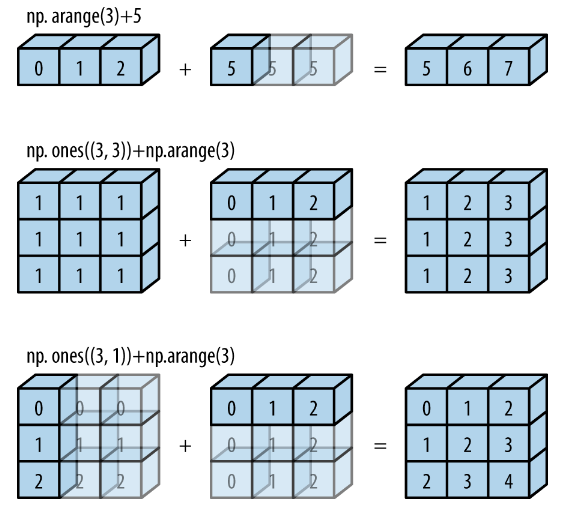


The light boxes represent the broadcasted values: again, this extra memory is **not actually allocated** in the course of the operation, but it can be useful conceptually to imagine that it is.

## Rules of Broadcasting

Broadcasting in NumPy follows a **strict set of rules** to determine the interaction between the two arrays:

* **Rule 1**: If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is **padded with ones on its leading (left) side**.
* **Rule 2**: If the shape of the two arrays does not match in any dimension, the array with shape equal to **1 in that dimension is stretched** to match the other shape.
* **Rule 3**: If in any dimension the sizes disagree and **neither is equal to 1**, an **error is raised**.

To make these rules clear, let's consider a few examples in detail.

### Broadcasting example 1

Let's look at adding a **two-dimensional array to a one-dimensional array**:

In [8]:
M = np.ones((2, 3))  # Shape: (2, 3)
a = np.arange(3)  # Shape: (3,)

Let's consider an operation on these two arrays. The shapes of the arrays are:

```
M.shape = (2, 3)
a.shape = (3,)
```

We see by **rule 1** that the array `a` has fewer dimensions, so we pad it on the left with ones:

```
M.shape -> (2, 3)
a.shape -> (1, 3)
```

By **rule 2**, we now see that the first dimension disagrees, so we stretch this dimension to match:

```
M.shape -> (2, 3)
a.shape -> (2, 3)
```

The shapes match, and we see that the final shape will be `(2, 3)`:

In [9]:
M + a

array([[1., 2., 3.],
       [1., 2., 3.]])

### Broadcasting example 2

Let's take a look at an example where **both arrays need to be broadcast**:

In [10]:
a = np.arange(3).reshape((3, 1))  # Shape: (3, 1)
b = np.arange(3)  # Shape: (3,)

Again, we'll start by writing out the shape of the arrays:

```
a.shape = (3, 1)
b.shape = (3,)
```

**Rule 1** says we must pad the shape of `b` with ones:

```
a.shape -> (3, 1)
b.shape -> (1, 3)
```

And **rule 2** tells us that we upgrade each of these ones to match the corresponding size of the other array:

```
a.shape -> (3, 3)
b.shape -> (3, 3)
```

Because the result matches, these shapes are **compatible**. We can see this here:

In [11]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

### Broadcasting example 3

Now let's take a look at an example in which the **two arrays are not compatible**:

In [12]:
M = np.ones((3, 2))  # Shape: (3, 2)
a = np.arange(3)  # Shape: (3,)

This is just a slightly different situation than in the first example: the matrix `M` is transposed. How does this affect the calculation? The shapes of the arrays are:

```
M.shape = (3, 2)
a.shape = (3,)
```

Again, **rule 1** tells us that we must pad the shape of `a` with ones:

```
M.shape -> (3, 2)
a.shape -> (1, 3)
```

By **rule 2**, the first dimension of `a` is stretched to match that of `M`:

```
M.shape -> (3, 2)
a.shape -> (3, 3)
```

Now we hit **rule 3**—the final shapes do not match, so these two arrays are **incompatible**, as we can observe by attempting this operation:

In [13]:
# Uncomment the following line:
# M + a  # Error
# ValueError: operands could not be broadcast together with shapes (3,2) (3,)

Note the potential confusion here: you could imagine making `a` and `M` compatible by, say, padding `a`'s shape with ones on the **right** rather than the left. But this is **not how the broadcasting rules work**! That sort of flexibility might be useful in some cases, but it would lead to potential areas of ambiguity. If right-side padding is what you'd like, you can do this explicitly by **reshaping the array** (we'll use the `np.newaxis` keyword introduced in "The Basics of NumPy Arrays" on page 42):

In [14]:
a   # Shape: (3,)

array([0, 1, 2])

In [15]:
M  # Shape: (3, 2)

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

In [16]:
a[:, np.newaxis].shape  # Shape: (3, 1)

(3, 1)

In [17]:
M + a[:, np.newaxis]
# [ Broadcasting Steps ]:
# (3, 2) + (3, 1)  --> Initial
# (3, 2) + (3, *2) --> Rule#2
# now fine

array([[1., 1.],
       [2., 2.],
       [3., 3.]])

Also note that while we've been focusing on the `+` operator here, these broadcasting rules apply to **any binary ufunc**.

## Broadcasting in Practice

Broadcasting operations form the core of many examples we'll see throughout this book. We'll now take a look at a couple simple examples of where they can be useful.

### Centering an array

In the previous section, we saw that ufuncs allow a NumPy user to **remove the need to explicitly write slow Python loops**. **Broadcasting extends this ability**. One commonly seen example is **centering an array of data**. Imagine you have an array of 10 observations, each of which consists of 3 values. Using the standard convention, we'll store this in a **10×3 array**:

In [18]:
X = np.random.random((10, 3))  # Shape: (10, 3)
X

array([[0.98278495, 0.55128726, 0.00583443],
       [0.51695298, 0.58326576, 0.19401889],
       [0.01382619, 0.79748837, 0.82142823],
       [0.29322937, 0.84314094, 0.05939349],
       [0.1612885 , 0.45448453, 0.08875658],
       [0.04383168, 0.58874073, 0.59197737],
       [0.67264319, 0.79127706, 0.50471203],
       [0.56538547, 0.34741858, 0.65412259],
       [0.65684882, 0.7889075 , 0.08399269],
       [0.4607967 , 0.54873873, 0.5171299 ]])

We can compute the **mean of each feature** using the `mean` aggregate across the first dimension:

In [19]:
Xmean = X.mean(axis=0)  # Shape: (3,)
# Mean of rows of each column (Mean of each column)
# NOTE: axis=0 is the access to be reduced, so from (10, 3) to (3,), reducing the 10
Xmean

array([0.43675879, 0.62947495, 0.35213662])

And now we can **center the X array** by subtracting the mean (this is a **broadcasting operation**):

In [20]:
X_centered = X - Xmean
# [ Broadcasting Steps ]:
# (10, 3) - (3,)     --> Initial
# (10, 3) - (*1, 3)  --> Rule#1
# (10, 3) - (*10, 3) --> Rule#2
X_centered

array([[ 0.54602617, -0.07818768, -0.34630219],
       [ 0.0801942 , -0.04620918, -0.15811773],
       [-0.4229326 ,  0.16801343,  0.46929161],
       [-0.14352942,  0.21366599, -0.29274313],
       [-0.27547029, -0.17499042, -0.26338005],
       [-0.39292711, -0.04073422,  0.23984075],
       [ 0.23588441,  0.16180211,  0.1525754 ],
       [ 0.12862668, -0.28205637,  0.30198597],
       [ 0.22009004,  0.15943255, -0.26814393],
       [ 0.02403791, -0.08073621,  0.16499328]])

To double-check that we've done this correctly, we can check that the centered array has **near zero mean**:

In [21]:
X_centered.mean(axis=0)

array([-3.33066907e-17,  0.00000000e+00,  2.22044605e-17])

To within-machine precision, the mean is now zero.

### Two-dimensional functions

One place that broadcasting is very useful is in **two-dimensional functions**. If we want to define a function `z = f(x, y)`, broadcasting can be used to compute the function across the grid:

In [22]:
# x and y have 50 steps from 0 to 5
x = np.linspace(0, 5, 50)  # Shape: (50,)
y = np.linspace(0, 5, 50)[:, np.newaxis]  # Shape: (50, 1)

z = np.sin(x) ** 10 + np.cos(10 + y * x) * np.cos(x)  # Shape: (50, 50)

# [ Broadcasting Steps ]:
# Target: temp = y * x ==> will be: [ col * row = matrix ]
# (50, 1) * (50,)       --> Initial
# (50, 1) * (1, 50)     --> Rule#1
# (50, *50) * (*50, 50) --> Rule#2
# Target: temp2 = np.cos(10+temp) * np.cos(x)
# (50, 50) * (50,)      --> Initial
# (50, 50) * (*1, 50)   --> Rule#1
# (50, 50) * (*50, 50)  --> Rule#2
# Target: z = np.sin(x) ** 10 + temp2
# (50,) + (50, 50)      --> Initial
# (*1, 50) + (50, 50)   --> Rule#1
# (*50, 50) + (50, 50)  --> Rule#2
print(x.shape); print(y.shape); print(z.shape);

(50,)
(50, 1)
(50, 50)


# 2- Masking, Comparisons, and Boolean Logic

This section covers the use of **Boolean masks** to examine and manipulate values within NumPy arrays. Masking comes up when you want to **extract, modify, count, or otherwise manipulate values** in an array based on some criterion: for example, you might wish to count all values greater than a certain value, or perhaps remove all outliers that are above some threshold. In NumPy, **Boolean masking** is often the most efficient way to accomplish these types of tasks.

## Comparison Operators as Ufuncs

We introduced ufuncs, and focused in particular on arithmetic operators. We saw that using `+`, `-`, `*`, `/`, and others on arrays leads to **element-wise operations**. NumPy also implements **comparison operators** such as `<` (less than) and `>` (greater than) as element-wise ufuncs. The result of these comparison operators is always an array with a **Boolean data type**. All six of the standard comparison operations are available:

In [23]:
x = np.array([1, 2, 3, 4, 5])

In [24]:
x < 3  # less than

array([ True,  True, False, False, False])

In [25]:
x > 3  # greater than

array([False, False, False,  True,  True])

In [26]:
x <= 3  # less than or equal

array([ True,  True,  True, False, False])

In [27]:
x >= 3  # greater than or equal

array([False, False,  True,  True,  True])

In [28]:
x != 3  # not equal

array([ True,  True, False,  True,  True])

In [29]:
x == 3  # equal

array([False, False,  True, False, False])

It is also possible to do an **element-by-element comparison of two arrays**, and to include **compound expressions**:

In [30]:
print(x); print(2 * x); print(x ** 2);
(2 * x) == (x ** 2)

[1 2 3 4 5]
[ 2  4  6  8 10]
[ 1  4  9 16 25]


array([False,  True, False, False, False])

As in the case of arithmetic operators, the comparison operators are implemented as **ufuncs in NumPy**; for example, when you write `x < 3`, internally NumPy uses `np.less(x, 3)`. A summary of the comparison operators and their equivalent ufunc is shown here:

| Operator | Equivalent ufunc |
|----------|------------------|
| `==` | `np.equal` |
| `!=` | `np.not_equal` |
| `<` | `np.less` |
| `<=` | `np.less_equal` |
| `>` | `np.greater` |
| `>=` | `np.greater_equal` |

Just as in the case of arithmetic ufuncs, these will work on **arrays of any size and shape**. Here is a two-dimensional example:

In [31]:
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3, 4))
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [32]:
x < 6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

In each case, the result is a **Boolean array**, and NumPy provides a number of straightforward patterns for working with these Boolean results.

## Working with Boolean Arrays

Given a Boolean array, there are a host of useful operations you can do. We'll work with `x`, the two-dimensional array we created earlier:

In [33]:
print(x)

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


### Counting entries

To **count the number of `True` entries** in a Boolean array, `np.count_nonzero` is useful:

In [34]:
# how many values less than 6?
np.count_nonzero(x < 6)

8

We see that there are eight array entries that are less than 6. Another way to get at this information is to use `np.sum`; in this case, `False` is interpreted as `0`, and `True` is interpreted as `1`:

In [35]:
# how many values less than 6?
np.sum(x < 6)

np.int64(8)

The benefit of `sum()` is that like with other NumPy aggregation functions, this summation can be done **along rows or columns** as well:

In [36]:
x < 6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

In [37]:
# how many values less than 6 in each row?
np.sum(x < 6, axis=1)
# Shape of x < 6: (3, 4)
# Shape of np.sum(.., axis=1): (3, ), sum of each row

array([4, 2, 2])

This counts the number of values less than 6 in each row of the matrix.

If we're interested in quickly checking whether **any or all** the values are true, we can use (you guessed it) `np.any()` or `np.all()`:

In [38]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [39]:
# are there any values greater than 8?
np.any(x > 8)

np.True_

In [40]:
# are there any values less than zero?
np.any(x < 0)

np.False_

In [41]:
# are all values less than 10?
np.all(x < 10)

np.True_

In [42]:
# are all values equal to 6?
np.all(x == 6)

np.False_

`np.all()` and `np.any()` can be used along **particular axes** as well. For example:

In [43]:
x < 8

array([[ True,  True,  True,  True],
       [ True, False,  True,  True],
       [ True,  True,  True,  True]])

In [44]:
# are all values in each row less than 8?
np.all(x < 8, axis=1)
# Shape of x < 8: (3, 4)
# Shape of np.all(.., axis=1): (3, ), np.all of each row
# np.all(row0) = True
# np.all(row1) = False
# np.all(row2) = True

array([ True, False,  True])

Here all the elements in the first and third rows are less than 8, while this is not the case for the second row.

Finally, a quick warning, Python has built-in `sum()`, `any()`, and `all()` functions. These have a **different syntax** than the NumPy versions, and in particular will **fail or produce unintended results** when used on multidimensional arrays. Be sure that you are using `np.sum()`, `np.any()`, and `np.all()` for these examples!

### Boolean operators

We've already seen how we might count, say, all elements less than 8. But what if we want to know about all elements **less than 8 and greater than 4**? This is accomplished through Python's **bitwise logic operators**, `&`, `|`, `^`, and `~`. Like with the standard arithmetic operators, NumPy overloads these as ufuncs that work **element-wise** on (usually Boolean) arrays.

For example, we can address this sort of compound question as follows:

In [45]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [46]:
# number of elements > 4 and < 8
np.sum((x > 4) & (x < 8))

np.int64(5)

Note that the **parentheses here are important**—because of operator precedence rules, with parentheses removed this expression would be evaluated as follows, which results in an error:

```python
x > (4 & x) < 8
```

Using the equivalence of **A AND B** and **NOT (A OR B)** (which you may remember if you've taken an introductory logic course), we can compute the same result in a different manner:

In [47]:
np.sum(~( (x <= 4) | (x >= 8) ))

np.int64(5)

Combining comparison operators and Boolean operators on arrays can lead to a wide range of efficient logical operations.

The following table summarizes the **bitwise Boolean operators** and their equivalent ufuncs:

| Operator | Equivalent ufunc |
|----------|------------------|
| `&` | `np.bitwise_and` |
| `\|` | `np.bitwise_or` |
| `^` | `np.bitwise_xor` |
| `~` | `np.bitwise_not` |


## Boolean Arrays as Masks

In the preceding section, we looked at aggregates computed directly on Boolean arrays. A more powerful pattern is to use **Boolean arrays as masks**, to **select particular subsets of the data themselves**. Returning to our `x` array from before, suppose we want an array of all values in the array that are less than, say, 5:

In [48]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

We can obtain a Boolean array for this condition easily, as we've already seen:

In [49]:
x < 5

array([[False,  True,  True,  True],
       [False, False,  True, False],
       [ True,  True, False, False]])

Now to **select these values from the array**, we can simply index on this Boolean array; this is known as a **masking operation**:

In [50]:
x[x < 5]  # Shape: (6,) --> 1D array of the matching elements

array([0, 3, 3, 3, 2, 4])

What is returned is a **one-dimensional array** filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is `True`.

We are then free to operate on these values as we wish using **aggregates**.

In [51]:
# mean of elements < 5
np.mean(x[x < 5])

np.float64(2.5)

By combining **Boolean operations, masking operations, and aggregates**, we can very quickly answer many sorts of questions for our dataset.

## Using the Keywords and/or Versus the Operators &/|

One common point of confusion is the difference between the keywords `and` and `or` on one hand, and the operators `&` and `|` on the other hand. **When would you use one versus the other?**

The difference is this: `and` and `or` gauge the **truth or falsehood of entire object**, while `&` and `|` refer to **bits within each object**.

When you use `and` or `or`, it's equivalent to asking Python to treat the object as a **single Boolean entity**. In Python, all nonzero integers will evaluate as `True`. Thus:

In [52]:
bool(42), bool(0), bool(-42)

(True, False, True)

In [53]:
bool(42 and 0)

False

In [54]:
bool(42 or 0)

True

When you use `&` and `|` on integers, the expression operates on the **bits of the element**, applying the `and` or the `or` to the individual bits making up the number:

In [55]:
bin(42)

'0b101010'

In [56]:
bin(59)

'0b111011'

In [57]:
bin(42 & 59)

'0b101010'

In [58]:
bin(42 | 59)

'0b111011'

Notice that the corresponding bits of the binary representation are compared in order to yield the result.

When you have an **array of Boolean values** in NumPy, this can be thought of as a string of bits where `1 = True` and `0 = False`, and the result of `&` and `|` operates in a similar manner as before:

In [59]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
print(A); print(B);
A | B

[ True False  True False  True False]
[ True  True  True False  True  True]


array([ True,  True,  True, False,  True,  True])

Using `or` on these arrays will try to evaluate the truth or falsehood of the **entire array object**, which is **not a well-defined value**:

In [60]:
# Uncomment the following line
# A or B  # Error

Similarly, when doing a Boolean expression on a given array, you should use `|` or `&` rather than `or` or `and`:

In [61]:
x = np.arange(10)
print(x); print(x > 4); print(x < 8);
(x > 4) & (x < 8)

[0 1 2 3 4 5 6 7 8 9]
[False False False False False  True  True  True  True  True]
[ True  True  True  True  True  True  True  True False False]


array([False, False, False, False, False,  True,  True,  True, False,
       False])

Trying to evaluate the truth or falsehood of the entire array will give the same `ValueError` we saw previously:

In [62]:
# Uncomment the following line
# (x > 4) and (x < 8)  # Error

So remember this: `and` and `or` perform a **single Boolean evaluation** on an entire object, while `&` and `|` perform **multiple Boolean evaluations** on the content (the individual bits or bytes) of an object. **For Boolean NumPy arrays**, the latter **(`&` and `|`) is nearly always the desired operation**.

# 3- Fancy Indexing

In the previous sections, we saw how to access and modify portions of arrays using simple indices (e.g., `arr[0]`), slices (e.g., `arr[:5]`), and Boolean masks (e.g., `arr[arr > 0]`). In this section, we'll look at another style of array indexing, known as **fancy indexing**. Fancy indexing is like the simple indexing we've already seen, but we pass **arrays of indices** in place of single scalars. This allows us to very quickly access and modify **complicated subsets of an array's values**.

## Exploring Fancy Indexing

Fancy indexing is conceptually simple: it means **passing an array of indices to access multiple array elements at once**. For example, consider the following array:

In [63]:
import numpy as np
rand = np.random.RandomState(42)

x = rand.randint(100, size=10)
print(x)

[51 92 14 71 60 20 82 86 74 74]


Suppose we want to access three different elements. We could do it like this:

In [64]:
[x[3], x[7], x[2]]

[np.int64(71), np.int64(86), np.int64(14)]

Alternatively, we can pass a **single list or array of indices** to obtain the same result:

In [65]:
ind = [3, 7, 4]  # Shape: (3,)
x[ind]  # Shape: (3,)

array([71, 86, 60])

With fancy indexing, the **shape of the result reflects the shape of the index arrays** rather than the shape of the array being indexed:

In [66]:
# All elements and indeces for clarification
print(x); print(list(range(len(x))));

[51 92 14 71 60 20 82 86 74 74]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [67]:
# Note the shape of the output
ind = np.array([[3, 7],
                [4, 5]])  # Shape: (2, 2)
x[ind]  # Shape: (2, 2)

array([[71, 86],
       [60, 20]])

Fancy indexing also works in **multiple dimensions**. Consider the following array:

In [68]:
X = np.arange(12).reshape((3, 4))
X

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

Like with standard indexing, the **first index refers to the row**, and the **second to the column**:

In [69]:
row = np.array([0, 1, 2])
col = np.array([2, 1, 3])
X[row, col]

array([ 2,  5, 11])

Notice that the first value in the result is `X[0, 2]`, the second is `X[1, 1]`, and the third is `X[2, 3]`. The **pairing of indices** in fancy indexing **follows all the broadcasting rules** that were mentioned. So, for example, if we combine a **column vector and a row vector** within the indices, we get a **two-dimensional result**:

In [70]:
print(X);
print('row:', row[:, np.newaxis]); print('col:', col);
print('shape of row ind:', row[:, np.newaxis].shape)
print('shape of col ind:', col.shape)
X[row[:, np.newaxis], col]
# [ Broadcasting Steps ]:
# pairing (3, 1) with (3,)     --> Initial
# pairing (3, 1) with (*1, 3)  --> Rule#1
# --> (*1, 3) is making col [[2 1 3]]
# pairing (3, *3) with (*3, 3) --> Rule#2
# --> (3, *3) is making row [[0,0,0],[1,1,1],[2,2,2]], repeats cols
# --> (*3, 3) is making col [[2,1,3],[2,1,3],[2,1,3]], repeats rows
# These are the final row and col ind after broadcasting

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
row: [[0]
 [1]
 [2]]
col: [2 1 3]
shape of row ind: (3, 1)
shape of col ind: (3,)


array([[ 2,  1,  3],
       [ 6,  5,  7],
       [10,  9, 11]])

Here, each row value is matched with each column vector, exactly as we saw in broadcasting of arithmetic operations. For example:

In [71]:
row[:, np.newaxis] * col

array([[0, 0, 0],
       [2, 1, 3],
       [4, 2, 6]])

It is always important to remember with fancy indexing that the **return value reflects the broadcasted shape of the indices**, rather than the shape of the array being indexed.

## Combined Indexing

For even more powerful operations, fancy indexing can be **combined with the other indexing schemes** we've seen:

In [72]:
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


We can combine **fancy and simple indices**:

In [73]:
X[2, [2, 0, 1]]

array([10,  8,  9])

We can also combine **fancy indexing with slicing**:

In [74]:
X[1:, [2, 0, 1]]

array([[ 6,  4,  5],
       [10,  8,  9]])

And we can combine **fancy indexing with masking**:

In [75]:
print(X)
print(row)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[0 1 2]


In [76]:
mask = np.array([1, 0, 1, 0], dtype=bool)
X[row[:, np.newaxis], mask]

array([[ 0,  2],
       [ 4,  6],
       [ 8, 10]])

See what happens if we only change **dtype of mask to int**:

In [77]:
col_ind = np.array([1, 0, 1, 0], dtype=int)
X[row[:, np.newaxis], col_ind]
# col_ind is the same as mask, but dtype int not bool
# this makes col_ind a fancy index (list of indeces)
# instead of a bool mask
# so broadcasting is performed here, but not on the mask above

# [ Broadcasting Steps ]:
# pairing (3, 1) with (4,)     --> Initial
# --> now row-ind [[0],[1],[2]], col-ind [1,0,1,0]
# pairing (3, 1) with (*1, 4)  --> Rule#1
# --> now row-ind [[0],[1],[2]], col-ind [[1,0,1,0]]
# pairing (3, *4) with (*3, 4) --> Rule#2
# --> now row-ind [[0,0,0,0],[1,1,1,1],[2,2,2,2]], repeats cols
#         col-ind [[1,0,1,0],[1,0,1,0],[1,0,1,0]], repeats rows

array([[1, 0, 1, 0],
       [5, 4, 5, 4],
       [9, 8, 9, 8]])

Now, it is considered column list of indeces (fancy index) not a mask.

All of these indexing options combined lead to a very **flexible set of operations** for accessing and modifying array values.

## Modifying Values with Fancy Indexing

Just as fancy indexing can be used to **access parts of an array**, it can also be used to **modify parts of an array**. For example, imagine we have an array of indices and we'd like to set the corresponding items in an array to some value:

In [78]:
x = np.arange(10)
print(x)
i = np.array([2, 1, 8, 4])
x[i] = 99
print(x)

[0 1 2 3 4 5 6 7 8 9]
[ 0 99 99  3 99  5  6  7 99  9]


We can use any **assignment-type operator** for this. For example:

In [79]:
x[i] -= 10
print(x)

[ 0 89 89  3 89  5  6  7 89  9]


Notice, though, that **repeated indices** with these operations can cause some potentially unexpected results. Consider the following:

In [80]:
x = np.zeros(10)
print(x)
x[[0, 0]] = [4, 6]
# NOTE: index is a list (fancy index) because here we want to access multiple elements
# but if you wrote x[0, 0] in a 2D array,
# this accesses a single element (at row 0, col 0)
# but here we have 1D array, so error,
# x[0,0] --> IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed
print(x)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[6. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Where did the 4 go? The result of this operation is to first assign `x[0] = 4`, followed by `x[0] = 6`. The result, of course, is that `x[0]` contains the value 6.


# 4- Sorting Arrays


## Fast Sorting in NumPy: np.sort and np.argsort

Although Python has built-in `sort` and `sorted` functions to work with lists, we won't discuss them here because NumPy's **`np.sort`** function turns out to be much more efficient and useful for our purposes. By default `np.sort` uses an **𝒪(N log N)**, quicksort algorithm, though mergesort and heapsort are also available. For most applications, the default quicksort is more than sufficient.

To return a **sorted version of the array without modifying the input**, you can use `np.sort`:

In [81]:
x = np.array([2, 1, 4, 3, 5])
np.sort(x)

array([1, 2, 3, 4, 5])

If you prefer to **sort the array in-place**, you can instead use the **`sort` method** of arrays:

In [82]:
x.sort()
print(x)

[1 2 3 4 5]


A related function is **`argsort`**, which instead returns the **indices of the sorted elements**:

In [83]:
x = np.array([2, 1, 4, 3, 5])
i = np.argsort(x)
print(i)

[1 0 3 2 4]


The first element of this result gives the **index of the smallest element**, the second value gives the index of the second smallest, and so on. These indices can then be used (via **fancy indexing**) to construct the sorted array if desired:

In [84]:
x[i]

array([1, 2, 3, 4, 5])

## Sorting along rows or columns

A useful feature of NumPy's sorting algorithms is the ability to sort along **specific rows or columns** of a multidimensional array using the **`axis` argument**. For example:

In [85]:
rand = np.random.RandomState(42)
X = rand.randint(0, 10, (4, 6))
print(X)

[[6 3 7 4 6 9]
 [2 6 7 4 3 7]
 [7 2 5 4 1 7]
 [5 1 4 0 9 5]]


In [86]:
# sort each column of X
np.sort(X, axis=0)

array([[2, 1, 4, 0, 1, 5],
       [5, 2, 5, 4, 3, 7],
       [6, 3, 7, 4, 6, 7],
       [7, 6, 7, 4, 9, 9]])

In [87]:
# sort each row of X
np.sort(X, axis=1)

array([[3, 4, 6, 6, 7, 9],
       [2, 3, 4, 6, 7, 7],
       [1, 2, 4, 5, 7, 7],
       [0, 1, 4, 5, 5, 9]])

Keep in mind that this treats **each row or column as an independent array**, and any relationships between the row or column values will be lost!